Baseline enzyme information
---------------------------
GK_in / GK_out = 187.40
PK_in / PK_out = 0.400
Baseline volume-averaged GK = 0.07013 uM = 70.13 nM
Baseline volume-averaged PK = 0.14000 uM = 140.00 nM

Scan finished.
Number of scanned conditions: 441
Number of successful solver runs: 439 / 441



,success,message,max_abs_residual_uM_per_s,GK_total_uM,PK_total_uM,GK_total_nM,PK_total_nM,GK_in_uM,GK_out_uM,PK_in_uM,...,v_GK_condensate_avg_uM_per_s,v_PK_condensate_avg_uM_per_s,net_ATP_condensate_avg_uM_per_s,v_GK_bulk_avg_uM_per_s,v_PK_bulk_avg_uM_per_s,net_ATP_bulk_avg_uM_per_s,ATP_outer_minus_center_uM,ATP_center_over_outer,GK_scale,PK_scale
0,True,The solution converged.,2.889181e-09,0.005,0.0100,5.0,10.0,0.289483,0.001545,0.004030,...,46.697765,0.336960,-46.360804,0.252997,0.816083,0.563087,24.532070,0.888968,0.071301,0.071429
1,True,The solution converged.,3.996485e-10,0.005,0.0345,5.0,34.5,0.289483,0.001545,0.013904,...,51.944347,0.458939,-51.485408,0.278407,0.903735,0.625329,27.153409,0.938887,0.071301,0.246429
2,True,The solution converged.,4.014853e-10,0.005,0.0590,5.0,59.0,0.289483,0.001545,0.023777,...,52.251891,0.553539,-51.698352,0.279926,0.907841,0.627915,27.141573,0.942256,0.071301,0.421429
3,True,The solution converged.,4.580487e-10,0.005,0.0835,5.0,83.5,0.289483,0.001545,0.033651,...,52.361094,0.646340,-51.714754,0.280462,0.908577,0.628114,27.027299,0.943664,0.071301,0.596429
4,True,The solution converged.,4.942945e-10,0.005,0.1080,5.0,108.0,0.289483,0.001545,0.043524,...,52.417449,0.737835,-51.679614,0.280736,0.908424,0.627688,26.888608,0.944542,0.071301,0.771429


CSV files saved:
1. GK_PK_ATP_center_outer_scan.csv
2. ATP_center_heatmap_matrix_uM.csv
3. ATP_outer_boundary_heatmap_matrix_uM.csv
4. ATP_outer_minus_center_heatmap_matrix_uM.csv
5. ATP_center_over_outer_heatmap_matrix.csv


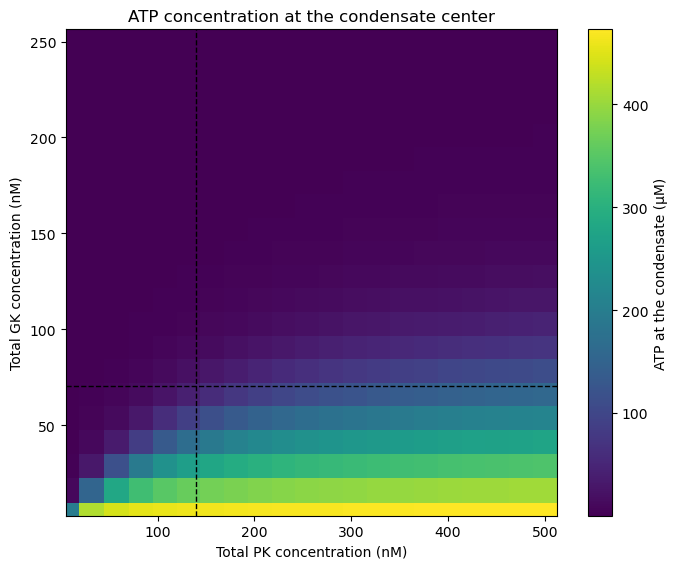

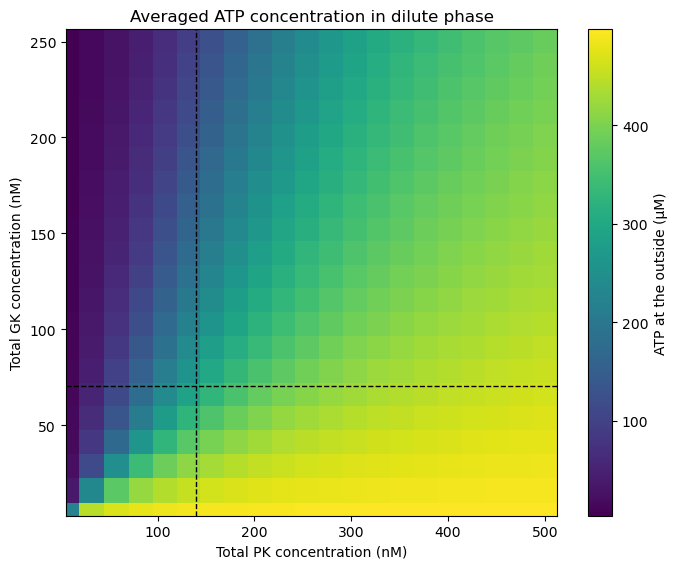

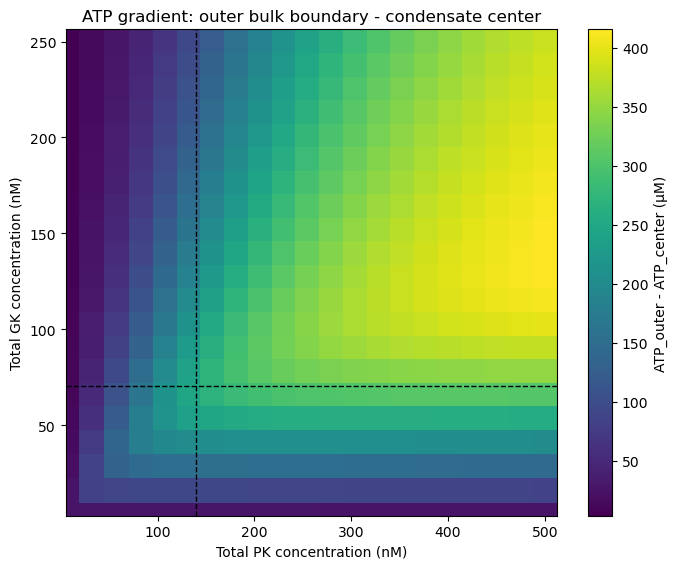

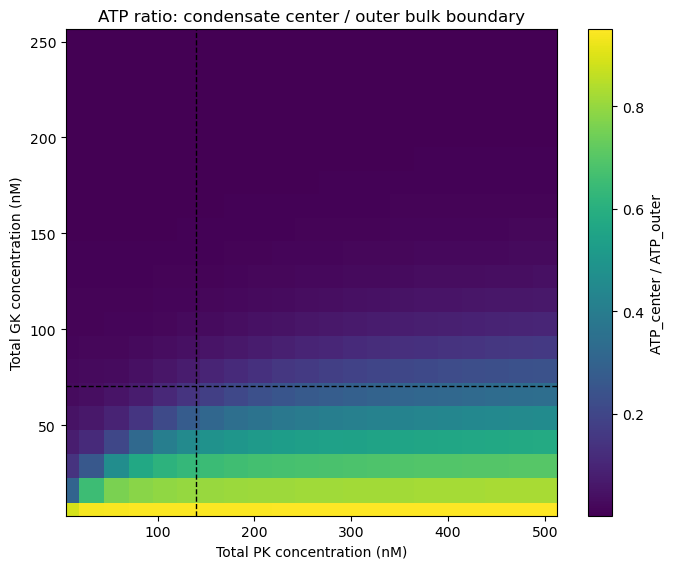

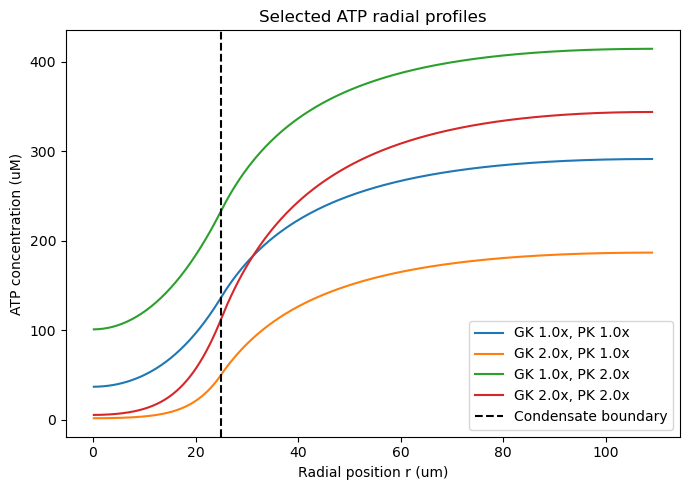

Baseline condition
GK_total = 70.13 nM
PK_total = 140.00 nM
GK_in = 4.0600 uM
GK_out = 0.0217 uM
PK_in = 0.0564 uM
PK_out = 0.1410 uM

ATP center = 36.672 uM
ATP outer boundary = 291.307 uM
ATP outer - center = 254.635 uM
ATP center / outer = 0.1259
Maximum absolute residual = 2.395e-09 uM/s


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root

# Geometry and physical parameters
phi = 0.012          # condensate volume fraction, 1.2%
R_cond = 25.0        # condensate radius, um

# Representative outer radius for spherical unit cell # phi = R_cond^3 / R_outer^3
R_outer = R_cond / phi**(1/3)

D_ATP = 460.0        # ATP diffusion coefficient, um^2/s
D_ADP = 460.0        # ADP diffusion coefficient, um^2/s

# Because D_ATP = D_ADP, use one D
D = D_ATP

# Initial nucleotide concentrations
ATP0 = 250.0         # uM
ADP0 = 250.0         # uM
N_total = ATP0 + ADP0    # uM

# Glycerol kinase baseline
GK_in_base = 4.06          # uM, inside condensate
GK_out_base = 0.021665     # uM, outside condensate

# Pyruvate kinase baseline
PK_in_base = 0.05642       # uM, inside condensate
PK_out_base = 0.141015     # uM, outside condensate

# Fixed partition ratios
GK_partition_ratio = GK_in_base / GK_out_base
PK_partition_ratio = PK_in_base / PK_out_base

# Volume-averaged total enzyme concentrations
GK_total_base = phi * GK_in_base + (1 - phi) * GK_out_base
PK_total_base = phi * PK_in_base + (1 - phi) * PK_out_base

print("Baseline enzyme information")
print("---------------------------")
print(f"GK_in / GK_out = {GK_partition_ratio:.2f}")
print(f"PK_in / PK_out = {PK_partition_ratio:.3f}")
print(f"Baseline volume-averaged GK = {GK_total_base:.5f} uM = {GK_total_base*1000:.2f} nM")
print(f"Baseline volume-averaged PK = {PK_total_base:.5f} uM = {PK_total_base*1000:.2f} nM")
print()

# Kinetic parameters of GK and PK
kcat_GK = 200.0      # s^-1
kcat_PK = 176.0      # s^-1

Km_ATP_GK = 48.6     # uM
Km_ADP_PK = 328.5    # uM


# Numerical grid
# N_in = 120
# N_out = 360
N_in = 80
N_out = 240

faces_in = np.linspace(0, R_cond, N_in + 1)
faces_out = np.linspace(R_cond, R_outer, N_out + 1)[1:]
faces = np.concatenate([faces_in, faces_out])

# Cell centers
r = 0.5 * (faces[:-1] + faces[1:])

# Total number of shells
N = len(r)

# Spherical shell volumes
volumes = (4.0 * np.pi / 3.0) * (faces[1:]**3 - faces[:-1]**3)

# Spherical face areas
areas = 4.0 * np.pi * faces**2

# Phase masks
inside = r < R_cond
outside = ~inside


# Diffusion operator precomputation
dr_centers = r[1:] - r[:-1]

diffusion_lower = np.zeros(N)
diffusion_upper = np.zeros(N)
diffusion_diag = np.zeros(N)

conductance = D * areas[1:N] / dr_centers

# For shell i, lower means dependence on shell i-1
diffusion_lower[1:] = conductance / volumes[1:]

# For shell i, upper means dependence on shell i+1
diffusion_upper[:-1] = conductance / volumes[:-1]

# Diagonal contribution
diffusion_diag[1:] -= conductance / volumes[1:]
diffusion_diag[:-1] -= conductance / volumes[:-1]

# Helper functions
def split_total_by_partition(E_total, partition_ratio):
    """
    Convert volume-averaged enzyme concentration into inside/outside
    concentrations while keeping the partition ratio fixed.

    E_total = phi * E_in + (1 - phi) * E_out
    partition_ratio = E_in / E_out
    """

    E_out = E_total / (phi * partition_ratio + (1 - phi))
    E_in = partition_ratio * E_out

    return E_in, E_out


def volume_average(x, mask):
    """
    Volume-weighted average over selected region.
    """
    return np.sum(x[mask] * volumes[mask]) / np.sum(volumes[mask])


def make_problem(GK_total, PK_total):
    """
    Build residual, Jacobian, and reaction-rate function for one GK/PK pair.

    GK_total and PK_total are volume-averaged enzyme concentrations in uM.
    The inside/outside ratio is fixed by GK_partition_ratio and PK_partition_ratio.
    """

    GK_in, GK_out = split_total_by_partition(GK_total, GK_partition_ratio)
    PK_in, PK_out = split_total_by_partition(PK_total, PK_partition_ratio)

    GK = np.where(inside, GK_in, GK_out)
    PK = np.where(inside, PK_in, PK_out)

    def reaction_rates(ATP):
        """
        Calculate local ATP/ADP and reaction rates.
        """

        ATP_safe = np.clip(ATP, 1e-12, N_total - 1e-12)
        ADP = N_total - ATP_safe

        # GK consumes ATP
        v_GK = kcat_GK * GK * ATP_safe / (Km_ATP_GK + ATP_safe)

        # PK regenerates ATP from ADP
        v_PK = kcat_PK * PK * ADP / (Km_ADP_PK + ADP)

        # Net ATP production
        net_ATP = v_PK - v_GK

        return ADP, v_GK, v_PK, net_ATP

    def residual(ATP):
        """
        Steady-state finite-volume residual for ATP.

        0 = D * Laplacian(ATP) + v_PK - v_GK
        """

        ADP, v_GK, v_PK, net_ATP = reaction_rates(ATP)

        flux = np.zeros(N + 1)

        # Fick's law across internal faces
        flux[1:N] = -D * areas[1:N] * (ATP[1:] - ATP[:-1]) / dr_centers

        # No-flux boundaries
        flux[0] = 0.0
        flux[N] = 0.0

        diffusive_influx = flux[:-1] - flux[1:]
        reaction_production = net_ATP * volumes

        res = (diffusive_influx + reaction_production) / volumes

        return res

    def jacobian(ATP):
        """
        Analytical Jacobian for faster repeated scanning.
        """

        ATP_safe = np.clip(ATP, 1e-12, N_total - 1e-12)
        ADP = N_total - ATP_safe

        # d(v_PK - v_GK)/dATP
        dnet_dATP = (
            -kcat_PK * PK * Km_ADP_PK / (Km_ADP_PK + ADP)**2
            -kcat_GK * GK * Km_ATP_GK / (Km_ATP_GK + ATP_safe)**2
        )

        J = np.zeros((N, N))
        idx = np.arange(N)

        J[idx, idx] = diffusion_diag + dnet_dATP
        J[idx[1:], idx[1:] - 1] = diffusion_lower[1:]
        J[idx[:-1], idx[:-1] + 1] = diffusion_upper[:-1]

        return J

    enzyme_info = {
        "GK_in_uM": GK_in,
        "GK_out_uM": GK_out,
        "PK_in_uM": PK_in,
        "PK_out_uM": PK_out,
    }

    return residual, jacobian, reaction_rates, enzyme_info


def solve_case(GK_total, PK_total, ATP_guess=None):
    """
    Solve one steady-state ATP profile for a given GK_total and PK_total.
    """

    residual, jacobian, reaction_rates, enzyme_info = make_problem(GK_total, PK_total)

    if ATP_guess is None:
        ATP_guess = np.interp(
            r,
            [0.0, R_cond, R_outer],
            [1.0, 100.0, 380.0]
        )

    solution = root(
        residual,
        ATP_guess,
        jac=jacobian,
        method="hybr",
        options={
            "xtol": 1e-10,
            "maxfev": 50 * N
        }
    )

    ATP = solution.x
    ADP, v_GK, v_PK, net_ATP = reaction_rates(ATP)

    max_abs_residual = np.max(np.abs(residual(ATP)))

    result = {
        "success": solution.success,
        "message": solution.message,
        "max_abs_residual_uM_per_s": max_abs_residual,

        "GK_total_uM": GK_total,
        "PK_total_uM": PK_total,
        "GK_total_nM": GK_total * 1000,
        "PK_total_nM": PK_total * 1000,

        "GK_in_uM": enzyme_info["GK_in_uM"],
        "GK_out_uM": enzyme_info["GK_out_uM"],
        "PK_in_uM": enzyme_info["PK_in_uM"],
        "PK_out_uM": enzyme_info["PK_out_uM"],

        "ATP_center_uM": ATP[0],
        "ATP_outer_boundary_uM": ATP[-1],
        "ATP_condensate_avg_uM": volume_average(ATP, inside),
        "ATP_bulk_avg_uM": volume_average(ATP, outside),
        "ATP_global_avg_uM": volume_average(ATP, np.ones_like(inside, dtype=bool)),

        "ADP_center_uM": ADP[0],
        "ADP_outer_boundary_uM": ADP[-1],
        "ADP_condensate_avg_uM": volume_average(ADP, inside),
        "ADP_bulk_avg_uM": volume_average(ADP, outside),

        "v_GK_condensate_avg_uM_per_s": volume_average(v_GK, inside),
        "v_PK_condensate_avg_uM_per_s": volume_average(v_PK, inside),
        "net_ATP_condensate_avg_uM_per_s": volume_average(net_ATP, inside),

        "v_GK_bulk_avg_uM_per_s": volume_average(v_GK, outside),
        "v_PK_bulk_avg_uM_per_s": volume_average(v_PK, outside),
        "net_ATP_bulk_avg_uM_per_s": volume_average(net_ATP, outside),

        "ATP_profile": ATP,
        "ADP_profile": ADP,
        "v_GK_profile": v_GK,
        "v_PK_profile": v_PK,
        "net_ATP_profile": net_ATP,
    }

    result["ATP_outer_minus_center_uM"] = (
        result["ATP_outer_boundary_uM"] - result["ATP_center_uM"]
    )

    result["ATP_center_over_outer"] = (
        result["ATP_center_uM"] / result["ATP_outer_boundary_uM"]
    )

    return result


# Define GK/PK scan range manually
scan_points = 21

# Enzyme concentration ranges directly with nM concentrations.
GK_min_nM = 5
GK_max_nM = 250

PK_min_nM = 10
PK_max_nM = 500

GK_total_values_nM = np.linspace(GK_min_nM, GK_max_nM, scan_points)
PK_total_values_nM = np.linspace(PK_min_nM, PK_max_nM, scan_points)

# Convert nM to uM because the simulation uses uM internally
GK_total_values = GK_total_values_nM / 1000
PK_total_values = PK_total_values_nM / 1000

# GK/PK parameter scan
center_map = np.full((len(GK_total_values), len(PK_total_values)), np.nan)
outer_map = np.full_like(center_map, np.nan)
difference_map = np.full_like(center_map, np.nan)
ratio_map = np.full_like(center_map, np.nan)

records = []

# Use continuation: each solution becomes the initial guess for the next one.
# This makes the scan more stable and faster.

ATP_guess = None

for i, GK_total in enumerate(GK_total_values):

    # Serpentine scan: alternate PK direction for smoother continuation
    if i % 2 == 0:
        pk_indices = range(len(PK_total_values))
    else:
        pk_indices = range(len(PK_total_values) - 1, -1, -1)

    for j in pk_indices:
        PK_total = PK_total_values[j]

        result = solve_case(
            GK_total=GK_total,
            PK_total=PK_total,
            ATP_guess=ATP_guess
        )

        ATP_guess = result["ATP_profile"]

        center_map[i, j] = result["ATP_center_uM"]
        outer_map[i, j] = result["ATP_outer_boundary_uM"]
        difference_map[i, j] = result["ATP_outer_minus_center_uM"]
        ratio_map[i, j] = result["ATP_center_over_outer"]

        record = {
            key: value
            for key, value in result.items()
            if not isinstance(value, np.ndarray)
        }

        record["GK_scale"] = GK_total / GK_total_base
        record["PK_scale"] = PK_total / PK_total_base

        records.append(record)

scan_df = pd.DataFrame(records)

print("Scan finished.")
print(f"Number of scanned conditions: {len(scan_df)}")
print(f"Number of successful solver runs: {scan_df['success'].sum()} / {len(scan_df)}")
print()

display(scan_df.head())

# Results to files
scan_df.to_csv("GK_PK_ATP_center_outer_scan.csv", index=False)

center_df = pd.DataFrame(
    center_map,
    index=GK_total_values * 1000,
    columns=PK_total_values * 1000
)
center_df.index.name = "GK_total_nM"
center_df.columns.name = "PK_total_nM"
center_df.to_csv("ATP_center_heatmap_matrix_uM.csv")

outer_df = pd.DataFrame(
    outer_map,
    index=GK_total_values * 1000,
    columns=PK_total_values * 1000
)
outer_df.index.name = "GK_total_nM"
outer_df.columns.name = "PK_total_nM"
outer_df.to_csv("ATP_outer_boundary_heatmap_matrix_uM.csv")

difference_df = pd.DataFrame(
    difference_map,
    index=GK_total_values * 1000,
    columns=PK_total_values * 1000
)
difference_df.index.name = "GK_total_nM"
difference_df.columns.name = "PK_total_nM"
difference_df.to_csv("ATP_outer_minus_center_heatmap_matrix_uM.csv")

ratio_df = pd.DataFrame(
    ratio_map,
    index=GK_total_values * 1000,
    columns=PK_total_values * 1000
)
ratio_df.index.name = "GK_total_nM"
ratio_df.columns.name = "PK_total_nM"
ratio_df.to_csv("ATP_center_over_outer_heatmap_matrix.csv")

print("CSV files saved:")
print("1. GK_PK_ATP_center_outer_scan.csv")
print("2. ATP_center_heatmap_matrix_uM.csv")
print("3. ATP_outer_boundary_heatmap_matrix_uM.csv")
print("4. ATP_outer_minus_center_heatmap_matrix_uM.csv")
print("5. ATP_center_over_outer_heatmap_matrix.csv")

# Heatmap plotting helper
def log_edges(values):
    """
    Convert log-spaced center values into edges for pcolormesh.
    """
    values = np.asarray(values)

    middle_edges = np.sqrt(values[:-1] * values[1:])
    first_edge = values[0]**2 / middle_edges[0]
    last_edge = values[-1]**2 / middle_edges[-1]

    edges = np.concatenate([[first_edge], middle_edges, [last_edge]])

    return edges


def plot_heatmap(matrix, title, colorbar_label):
    """
    Plot heatmap with PK on x-axis and GK on y-axis.
    """

    x_edges = log_edges(PK_total_values * 1000)  # nM
    y_edges = log_edges(GK_total_values * 1000)  # nM

    plt.figure(figsize=(7, 5.8))

    plt.pcolormesh(
        x_edges,
        y_edges,
        matrix,
        shading="auto"
    )

    plt.axvline(PK_total_base * 1000, linestyle="--", color="black", linewidth=1)
    plt.axhline(GK_total_base * 1000, linestyle="--", color="black", linewidth=1)

    plt.xlabel("Total PK concentration (nM)")
    plt.ylabel("Total GK concentration (nM)")
    plt.title(title)

    cbar = plt.colorbar()
    cbar.set_label(colorbar_label)

    plt.tight_layout()
    plt.show()



# Plot heatmaps
plot_heatmap(
    center_map,
    title="ATP concentration at the condensate center",
    colorbar_label="ATP at the condensate (µM)"
)

plot_heatmap(
    outer_map,
    title="Averaged ATP concentration in dilute phase",
    colorbar_label="ATP at the outside (µM)"
)

plot_heatmap(
    difference_map,
    title="ATP gradient: outer bulk boundary - condensate center",
    colorbar_label="ATP_outer - ATP_center (µM)"
)

plot_heatmap(
    ratio_map,
    title="ATP ratio: condensate center / outer bulk boundary",
    colorbar_label="ATP_center / ATP_outer"
)


# Plot selected radial profiles
selected_conditions = [
    (1.0, 1.0),    # baseline
    (2.0, 1.0),    # higher GK
    (1.0, 2.0),    # higher PK
    (2.0, 2.0),    # both higher
]

plt.figure(figsize=(7, 5))

for GK_scale, PK_scale in selected_conditions:

    GK_total = GK_total_base * GK_scale
    PK_total = PK_total_base * PK_scale

    result = solve_case(GK_total, PK_total)

    plt.plot(
        r,
        result["ATP_profile"],
        label=f"GK {GK_scale:.1f}x, PK {PK_scale:.1f}x"
    )

plt.axvline(R_cond, linestyle="--", color="black", label="Condensate boundary")
plt.xlabel("Radial position r (um)")
plt.ylabel("ATP concentration (uM)")
plt.title("Selected ATP radial profiles")
plt.legend()
plt.tight_layout()
plt.show()


# Print baseline result for comparison
baseline_result = solve_case(GK_total_base, PK_total_base)

print("============================================================")
print("Baseline condition")
print("============================================================")
print(f"GK_total = {baseline_result['GK_total_nM']:.2f} nM")
print(f"PK_total = {baseline_result['PK_total_nM']:.2f} nM")
print(f"GK_in = {baseline_result['GK_in_uM']:.4f} uM")
print(f"GK_out = {baseline_result['GK_out_uM']:.4f} uM")
print(f"PK_in = {baseline_result['PK_in_uM']:.4f} uM")
print(f"PK_out = {baseline_result['PK_out_uM']:.4f} uM")
print()
print(f"ATP center = {baseline_result['ATP_center_uM']:.3f} uM")
print(f"ATP outer boundary = {baseline_result['ATP_outer_boundary_uM']:.3f} uM")
print(f"ATP outer - center = {baseline_result['ATP_outer_minus_center_uM']:.3f} uM")
print(f"ATP center / outer = {baseline_result['ATP_center_over_outer']:.4f}")
print(f"Maximum absolute residual = {baseline_result['max_abs_residual_uM_per_s']:.3e} uM/s")